# Model Development and Evaluation
## Wisconsin Diagnostic Breast Cancer 

---

## Motivating Problem
#### Can we develop a machine learning model that uses cell morphology features to help radiologists differentiate malignant from benign breast masses, thereby reducing unnecessary biopsies without compromising cancer detection rates?

This notebook trains and evaluates several machine learning models to classify breast tumors as benign or malignant using the [Wisconsin Diagnostic Breast Cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), which contains features describing 10 core characteristics of cell nuclei present in the digitized images of fine needle aspirates.  

**Models Evaluated**:
- Logistic Regression (No regularization)
- Logistic Regression (L1 regularization)
- Logistic Regression (L2 regularization)
- Random Forest
- Support Vector Machine

**Evaluation Metrics**: accuracy, sensitivity, specificity, AUC-ROC, and confusion matrices.

## Import Modules

In [1]:
import sys
from pathlib import Path

# Get repo root (one level above notebooks/)
repo_root = Path().resolve().parent
src_path = repo_root / "src"

# Add src folder to Python path
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix

# import custom modules (located in src/)
import visualization as vis 
from preprocessing import load_raw_data, get_Xy, split_data
from pipelines import logistic_pipeline, rf_pipeline, svm_pipeline
# from tune import get_param_grid, tune_model, extract_feature_importance
from evaluate import tune_and_evaluate, cross_validate_model
from compare import compare_models, stack_tuned_metrics

# Suppress sklearn warnings (clean output)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# settings
sns.set_style(style="white")
print("> Loaded required libraries")

> Loaded required libraries


In [ ]:
# hard-coded variables or flags
cols = {"malignant": "darkblue", "benign": "#04b2d1"} # target
measures = ["mean", "error", "worst"]
measures_cols = {"mean": "#3498DB", "error": "#F39C12", "worst": "#E74C3C"} # measures

## Data & Model Preparation
The raw dataset is loaded and cleaned using a helper function. Cleaning steps include standardizing column names and encoding the target variable (malignant = 1, benign = 0). The data are separated into features (X) and target (y) before being split into training and test sets. 

As discussed in the [exploratory data analysis (01_eda.ipynb)](https://github.com/sarahcreighton/breast-cancer-classifier/blob/main/notebooks/01_eda.ipynb), the dataset contains more benign tumors (63%) than malignant tumors (37%). Although the class imbalance is moderate and unlikely to severely bias model training, we stratified sampling to preserve class balance. All analyses used a 80/20 train-test split and stratified sampling.

Our analyses make use of scikit-learn pipelines to ensure proper scaling (standardization) for the logistic regression and SVM models, and to eliminate the risk of data leakage. Scaling is particularly important for this dataset due to the high degree of multicollinearity.  

In [3]:
data_path = "../data/raw/wdbc.data"
df = load_raw_data(data_path)
X, y = get_Xy(df) 
X_train, X_test, y_train, y_test = split_data(X, y)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 455
Test samples: 114


## PCA Visualization of Tumor Types
We used Principle Components Analysis (PCA) to reduce the high-dimensional feature space of our dataset to $n$ lower-dimensions to visualize how benign and malignant tumors separate. Projection onto the first two principle components reveals a strong separation between malignant and benign samples, indicating that the underlying feature space contains structure suitible for classification. The first two principle components explain roughly 63% of the variance.

<!-- <div><center><img src="../results/figures/02_pca.png" width="400"/> </center></div> -->

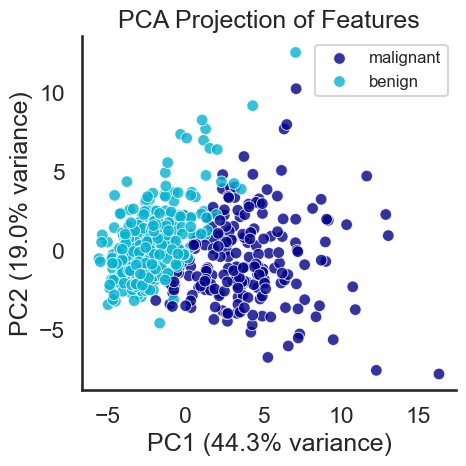

In [4]:
vis.plot_pca(df, palette=cols,figsize=(5,5))

## Baseline Model Comparisons
We tested 3 different baseline classifier models: logistic regression, random forest, and support vector, using scikit-learn's default settings to identify which algorithm family works best for our dataset. 

In [5]:
base_models = {
    "Logistic (Baseline)": logistic_pipeline(),
    "Random Forest (Baseline)": rf_pipeline(),
    "Support Vector (Baseline)": svm_pipeline()
}

base_res, base_cms, base_trained_models = compare_models(
    base_models, X_train, y_train, X_test, y_test
)

# Sort and highlight the max ROC-AUC
base_results = base_res.sort_values(by="ROC-AUC", ascending=False)
base_results.style.highlight_max(color="seagreen")

,Accuracy,Sensitivity,Specificity,ROC-AUC,Precision,F1-Score
Model,,,,,,
Logistic (Baseline),0.964900,0.928600,0.986100,0.996000,0.975000,0.951200
Support Vector (Baseline),0.973700,0.928600,1.000000,0.994700,1.000000,0.963000
Random Forest (Baseline),0.973700,0.928600,1.000000,0.992900,1.000000,0.963000


### Observations:
All three baseline models achieved very high performance across all evaluation metrics, reflecting the clean and well-separated nature of the Wisconsin Breast Cancer dataset. Sensitivity was identical across all models, so specificity became the key differentiator, leading us to prioritize Support Vector Machine for its perfect specificity while also selecting Logistic Regression for further tuning due to its interpretability.

**Model Selection Rationale**: 
- support vector machine was selected because it achieved perfect specificity while maintaining the same sensitivity as other models
- logistic regression (L2) was also selected for further tuning due to its interpretability, which is important for clinical applications

## Model Tuning
Hyperparameter tuning was performed using cross-validated grid search to optimize key parameters for the selected models while maintaining a consistent evaluation framework. 

In [6]:
# tune and evaluate logistic regression model
lr_metrics, lr_cm, best_lr, best_lr_params, best_lr_score = tune_and_evaluate(
    "Logistic", logistic_pipeline, X_train, y_train, X_test, y_test
)

# tune and evaluate SVM model
svm_metrics, svm_cm, best_svm, best_svm_params, best_svm_score = tune_and_evaluate(
    "SVM", svm_pipeline, X_train, y_train, X_test, y_test
)

# tune and evaluate RF model (for feature importance)
rf_metrics, rf_cm, best_rf, best_rf_params, best_rf_score = tune_and_evaluate(
    "RF", rf_pipeline, X_train, y_train, X_test, y_test
)

In [7]:
# return table of results
tuned_results = stack_tuned_metrics(
    [lr_metrics, svm_metrics, rf_metrics],
    ["Logistic (Tuned)", "Support Vector (Tuned)", "Random Forest (Tuned)"]
)
# sort by desired metric
tuned_results.sort_values("ROC-AUC", ascending=False).style.highlight_max(color="seagreen")

,Accuracy,Sensitivity,Specificity,ROC-AUC,Precision,F1-Score
Logistic (Tuned),0.964900,0.928600,0.986100,0.996000,0.975000,0.951200
Random Forest (Tuned),0.973700,0.928600,1.000000,0.995000,1.000000,0.963000
Support Vector (Tuned),0.973700,0.928600,1.000000,0.994700,1.000000,0.963000


#### Observations:
- Hyperparameter tuning produced no meaningful changes in model performance
- All tuned models achieved nearly identical metrics to their baseline 
- Random forest and support vector machine maintained the highest overall accuracy and perfect specificity 
- Logistic regression continued to show the highest ROC-AUC but slightly lower specificity 


These results suggest that baseline models were already near optimal for this dataset, and futher tuning provided little meaningful improvement. Optimal hyperparameters for each tuned model are reported for reproducibility.

In [8]:
tuned_models = {
    "Logistic (Tuned)": (best_lr, best_lr_params, best_lr_score),
    "Support Vector (Tuned)": (best_svm, best_svm_params, best_svm_score),
    "Random Forest (Tuned)": (best_rf, best_rf_params, best_rf_score)
}

rows = []
for name, (model, params, score) in tuned_models.items():
    row = {"Model": name, "Best Score": score, **params}
    rows.append(row)

tuned_params_df = pd.DataFrame(rows).fillna("-")
tuned_params_df

,Model,Best Score,model__C,model__penalty,model__solver,model__kernel,model__max_depth,model__n_estimators
0,Logistic (Tuned),0.995262,1.0,l2,lbfgs,-,-,-
1,Support Vector (Tuned),0.995045,1.0,-,-,rbf,-,-
2,Random Forest (Tuned),0.990079,-,-,-,-,5.0,100.0


## Cross Validation
Cross-validation was used to evaluate model stability and ensure that performance was not dependent on a single train-test split. The results showed consistently high ROC-AUC across folds with minimal variance, indicating stable model performance. Due to the small size and separability of the dataset, differences between models were minimal across both cross-validation and held-out test evaluation.

In [9]:
scoring = "roc_auc"
selected_models = {
    "Logistic (Tuned)": best_lr,
    "Support Vector (Tuned)": best_svm,
    "Random Forest (Tuned)": best_rf
}

for name, model in selected_models.items():
    cv_metrics = cross_validate_model(model, X_train, y_train, cv=10, scoring="recall")

    print(f"{name}")
    print(f"Mean ROC-AUC: {cv_metrics['cv_mean']:.3f} ± {cv_metrics['cv_std']:.3f}\n")
    # print(f"Fold scores: {cv_metrics['cv_scores']}\n")

Logistic (Tuned)
Mean ROC-AUC: 0.953 ± 0.069

Support Vector (Tuned)
Mean ROC-AUC: 0.953 ± 0.058

Random Forest (Tuned)
Mean ROC-AUC: 0.935 ± 0.055



## ROC Curves
ROC curves for the tuned logistic regression and SVM models are shown below for completeness. Given the high performance of both classifiers, the curves overlap almost entirely and do not reveal meaningful differences.

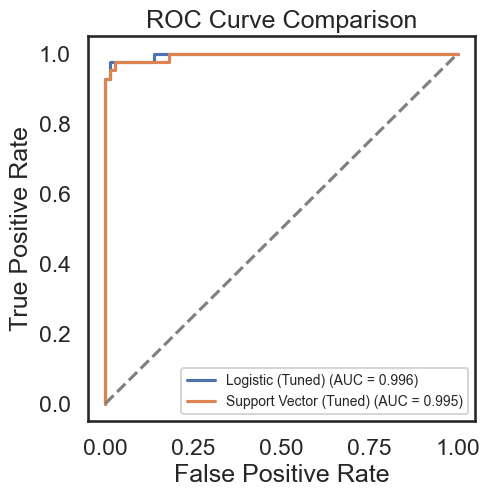

In [10]:
models_to_plot = {
    "Logistic (Tuned)": best_lr,
    "Support Vector (Tuned)": best_svm
}
vis.plot_roc_curves(models_to_plot, X_test, y_test,figsize=(5,5))

## Interpretability
For the random forest model, feature importance measures how much each feature contributes to reducing classification error. The top features indicate which variables the model relied on most heavily to distinguish malignant from benign tumors. 

Similarly, for the logistic regression model, the magnitude of the coefficients reflects the influence of each feature on the predicted probability of malignancy. 

Together, these analyses highlight the most predictive features and provide insight into which measurements are most relevant for clinical interpretation.

### Feature Importance

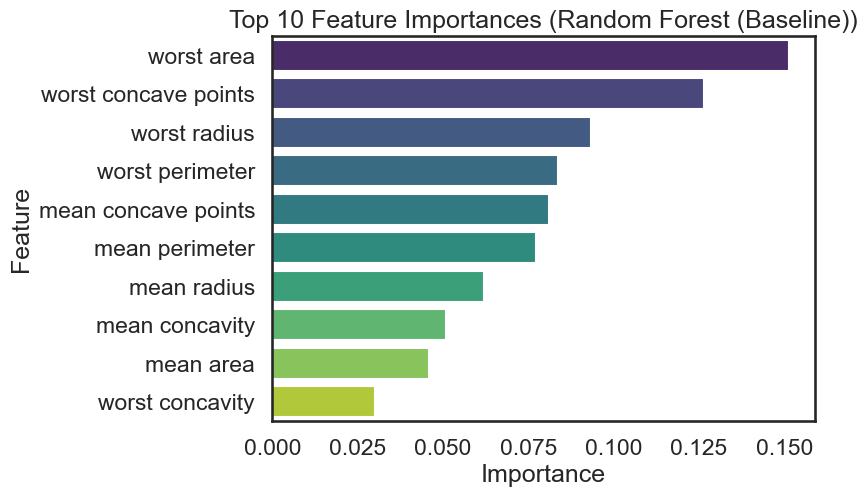

In [11]:
vis.plot_rf_feature_importances(base_trained_models, "Random Forest (Baseline)", X_train, top_n=10)

### Coefficient Magnitude

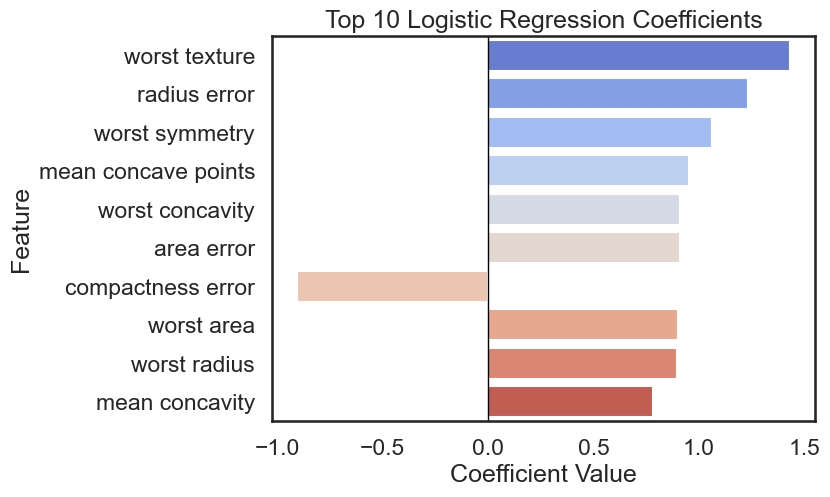

In [12]:
vis.plot_logistic_coefficients(best_lr, X_train, top_n=10)

#### Observations:
Across the models, several features consistently emerage as most predictive. 

For the random forest, size- and shape-related measurements such as worst area, worst concave points, and worst radius dominate the top 10 importances, reflecting their strong contribution to distinguishing malignant from benign tumors. 

In the logistic regression model, both geometric (e.g., size, shape) features and error-related measures (e.g., radius error, area error, compactness error) appear among the top coefficients, indicating that subtle deviations in these characteristics also influence the predicted probability of malignancy. 

Together, these results highlight that tumor size, shape irregularities, and measurement deviations are key factors driving model predictions.

### Threshold Comparisons
We explored how changing the prediction threshold affects model performance. Lowering the threshold increases sensitivity, helping to catch more malignant cases, but reduces specificity, leading to more false positives. These curves allow us to select a threshold that balances patient safety with avoiding unnecessary procedures.

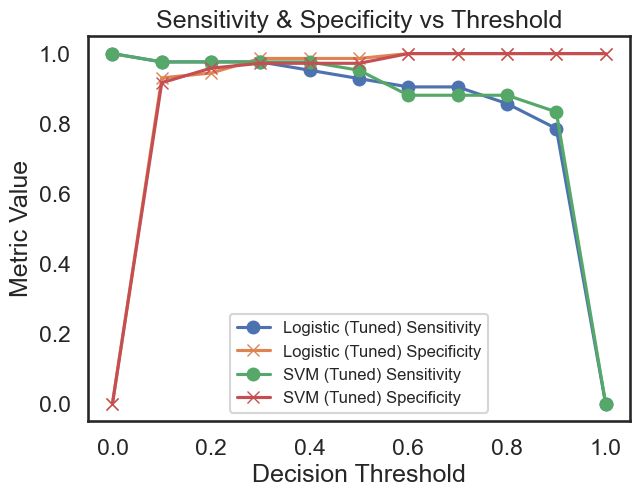

In [13]:
models_to_plot = {
    "Logistic (Tuned)": best_lr, 
    "SVM (Tuned)": best_svm
    }
vis.plot_sensitivity_specificity(models_to_plot, X_test, y_test)

#### Observations:
Sensitivity is consistently high across nearly the entire range of thresholds, reflecting the dataset's clean separation between malignant and benign tumors. Even with thresholds lowered toward 0, sensitivity remains near 1, while specificity decreases only gradually. This indicates that the models can maintain excellent detection of malignant cases with minimal trade-off in avoiding false positives, which aligns with the dataset's well-separated features and near-perfect baseline performance.

## Summary & Clinical Relevance
Our models demonstrate near-perfect discrimination between malignant and benign tumors on the Wisconsin Breast Cancer dataset, with both logistic regression and SVM achieving high sensitivity and specificity. Clinically, this suggests that using these features - primarily related to tumor size and shape - could reliably identify high-risk cases while minimizing unncessary procedures. However, the very high performance also reflects the clean, well-separated nature of teh dataset, and real-world variability may reduce accuracy.

### Key Takeaways
- models achieve excellent sensitivity and specificity, indicating strong potential for reliable cancer detection
- tumor size and shape features are the most predictive, aligning with clinical intuition
- extremely high accuracy may overstate real-world performance due to the dataset's clean separation

---

_Last Updated: 2026-03-06_